This LBM code implemented using pure numpy. The code is named RING. Lets import some library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Function to compute macroscopic variables from distribution function 

In [2]:
def compute_macro_quantities(f,obstacles,ex,ey):
    """
    compute macroscopic variables from moments of f's
    
    Parameters
    ----------
        f: ndarray
            distribution function
        obstacles: ndarray
            containing >0 values for solid phase
        ex: ndarray
            lattice velocity in x direction
        ey: ndarray
            lattice velocity
        
    Returns
    -------
        rho: ndarray
            density computed from f
        ux: ndarray
            velocity in x direction computed from f
        uy: ndarray
            velocity in y direction computed from f
    """
    rho = f.sum(0)
    fieix = f*ex[:,None,None]
    ux   = (rho/(1e-30+rho)**2)*fieix.sum(0)
    fieiy = f*ey[:,None,None]
    uy   = (rho/(1e-30+rho)**2)*fieiy.sum(0)
    #set solid node fluxes and density to zero 
    rho  *=1.*(obstacles<=0)
    ux   *=1.*(obstacles<=0)
    uy   *=1.*(obstacles<=0)
    return rho,ux,uy

function to compute equilibrium distribution function

In [3]:
def equillibrium(f,rho,ux,uy,obstacles,ex,ey,es,w):
     """
     computes equilibrium distribution function
    
    Parameters
    ----------
        f: ndarray
            distribution function
        rho: ndarray
            density computed from f
        ux: ndarray
            velocity in x direction computed from f
        uy: ndarray
            velocity in y direction computed from f
        obstacles: ndarray
            containing >0 values for solid phase
        ex: ndarray
            lattice velocity in x direction
        ey: ndarray
            lattice velocity
        es: float
            pseudo velocity of sound
        w: ndarray
            lattice weights

    Returns
    -------
        feq: ndarray
            equilibrium distribution function
     """
     #compute equillibrium distribution function
     Termorder1  = (1./es**2)*(ex[:,None,None]* ux + ey[:,None,None]*uy)
     euxy        = 1.*ex[:,None,None]*ey[:,None,None]*ux*uy
     euxx        = 1.*ex[:,None,None]*ex[:,None,None]*ux*ux
     euyy        = 1.*ey[:,None,None]*ey[:,None,None]*uy*uy
     eu2         = 2.*euxy + euxx + euyy
     ux2         = 1.*ux*ux
     uy2         = 1.*uy*uy
     u2          = ux2+uy2
     Termorder2  =(0.5/es**4)*eu2 - (0.5/es**2)*u2     
     feq= w[:,None,None] *rho *(1+ Termorder1+ Termorder2)
     return feq

perform collision step

In [4]:
def collision(f,rho,ux,uy,obstacles,ex,ey,es,w,omega=1):
     """
     executes collision step
     
     Parameters
     ----------
         f: ndarray
            distribution function
        rho: ndarray
            density computed from f
        ux: ndarray
            velocity in x direction computed from f
        uy: ndarray
            velocity in y direction computed from f
        obstacles: ndarray
            containing >0 values for solid phase
        ex: ndarray
            lattice velocity in x direction
        ey: ndarray
            lattice velocity in y direction     
        es: float
            pseudo velocity of sound
        w: ndarray
            lattice weights
        omega: float
            inverse of relaxation parameter

     Returns
     -------
         f: ndarray
             f after executing collision step
     """
     feq= equillibrium(f,rho,ux,uy,obstacles,ex,ey,es,w)
     #compute bgk collision
     f = (1.-omega)*f +(omega*feq)
     f *= 1.*(obstacles<=0) 
     return f

perform propogation step

In [5]:
def propogation(f,ex,ey,obstacles):
    """
    executes periodic propogation step with bounceback for obstacles 
     
     Parameters
     ----------
         f: ndarray
            distribution function
        obstacles: ndarray
            containing >0 values for solid phase
        ex: ndarray
            lattice velocity in x direction
        ey: ndarray
            lattice velocity in y direction     
     Returns
     -------
         f: ndarray
             f after executing propogation step
    """
    ex =ex.astype(int)
    ey =ey.astype(int)    
    solid_node_in_path = np.zeros(np.shape(f))
    fc_bb              = np.zeros(np.shape(f))
    solid_node_exist   = 1.*(obstacles >0)
    idx                =np.array([0,3,4,1,2,7,8,5,6])        
    #see if solid node exist on propogation path
    for j in range(9):
        #solid flag in path
        solid_node_in_path[idx[j]]=solid_node_exist.copy()
        solid_node_in_path[idx[j]]= np.roll(solid_node_in_path[idx[j]],-ex[j],axis=1)
        solid_node_in_path[idx[j]]= np.roll(solid_node_in_path[idx[j]], ey[j],axis=0)    
    f_propogation      = f.copy()
    for j in range(9):
        #bounceback
        fc_bb[idx[j]]= f[j].copy()
        #propogation
        f_propogation[j] = np.roll(f_propogation[j], ex[j],axis=1)
        f_propogation[j] = np.roll(f_propogation[j],-ey[j],axis=0)
        f = f_propogation * (solid_node_in_path==0.)  + fc_bb * (solid_node_in_path==1.)        
    return f

apply forcing

In [6]:
def apply_forcing(rho,ux,uy,fx=0,fy=0,omega=1):
    """
    applies gravitational forcing by modifying velocity
    
    Parameters
    ----------
    
        rho: ndarray
            density computed from f
        ux: ndarray
            velocity in x direction computed from f
        uy: ndarray
            velocity in y direction computed from f
        obstacles: ndarray
            containing >0 values for solid phase
        fx: ndarray
            forcing in x direction
        fy: ndarray
            forcing in y direction     
        omega: float
            inverse of relaxation parameter

     Returns
     -------
         ux,uy: ndarray
             updated velocity by applying forcing term
    """
    ux +=(fx*rho)/((rho+1e-30)**2*omega)
    uy +=(fy*rho)/((rho+1e-30)**2*omega)
    return ux,uy

Lets test our implementation

In [7]:
def test_lb():
    """
    simple example of poiseulle's flow 
    """
    #input
    lx=100
    ly=50
    ts=15000
    gx=1e-4
    #intialize problem setup
    rowlength=ly
    collength = lx
    rho =np.zeros((rowlength,collength))
    ux  =np.zeros((rowlength,collength))
    uy  =np.zeros((rowlength,collength))
    obstacles=np.zeros((rowlength,collength))
    obstacles[0,:]=1
    obstacles[-1,:]=1
    f=np.zeros((9,rowlength,collength))
    f[1,:,:] =1./9.
    f[2,:,:] =1./9.
    f[3,:,:] =1./9.
    f[4,:,:] =1./9.
    f[5,:,:] =1./36.
    f[6,:,:] =1./36.
    f[7,:,:] =1./36.
    f[8,:,:] =1./36.
    f[0,:,:] =4./9. 
    ex=np.array([0, 1, 0,-1, 0, 1,-1,-1, 1])
    ey=np.array([0, 0, 1, 0,-1, 1, 1,-1,-1])
    es=1./3.**0.5
    w=np.array([4./9.,1./9.,1./9.,1./9.,1./9.,1./36.,1./36.,1./36.,1./36.])
    for t in range(ts):
        #compute macro quantites
        rho,ux,uy= compute_macro_quantities(f,obstacles,ex,ey)   

        #apply forcing
        ux,uy = apply_forcing(rho,ux,uy,fx=gx)
    
        #collide
        f = collision(f,rho,ux,uy,obstacles,ex,ey,es,w)
    
        #stream
        f = propogation(f,ex,ey,obstacles)

    plt.figure(1)
    plt.quiver(ux,uy)
    plt.show()
    #plot curve
    ulb=ux[:,int(lx/2)]
    plt.figure(2)
    plt.plot(ulb)
    plt.show()

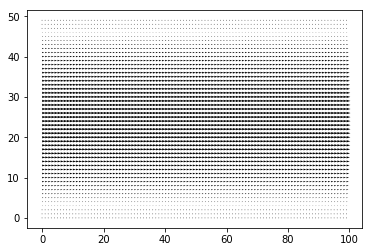

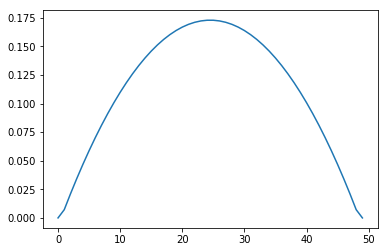

Wall time: 2min 54s


In [8]:
%%time
test_lb()

MLUPS of code:

In [9]:
(100*50*15000*1e-6)/174

1.0695187165775402